In [0]:
%pip install databricks-langchain

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/87.7 kB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 6.4 MB/s eta 0:00:00

*** WARNING: max output size exceeded, skipping output. ***

sion is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/752.6 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 752.6/752.6 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/92.0 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/8.8 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━ 5.2/8.8 MB 156.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 8.8/8.8 MB 153.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [0]:
import pandas as pd
import numpy as np
from databricks_langchain.chat_models import ChatDatabricks
from langchain_core.messages import SystemMessage, HumanMessage
import json
import re

In [0]:
df = pd.read_csv("/Volumes/daz_aitraining_cat/aitraining/aitraining_volume/fed_sentiment_training.csv", sep='\t')

n = len(df)
test_size = int(0.1 * n)
indices = np.random.RandomState(95).permutation(n)
train_idxs, test_idxs = indices[test_size:], indices[:test_size]

df_test = df.iloc[test_idxs][["text", "sentiment"]].copy()
df_test.head()

,text,sentiment
1089,Higher energy and other costs have the potenti...,hawkish
557,The Committee will continue to monitor the eco...,neutral
552,The Committee perceives the upside and downsid...,neutral
630,The Committee expects inflation to moderate la...,hawkish
464,Information received since the Federal Open Ma...,dovish


In [0]:
# Initialize the chat model
chat_model = ChatDatabricks(
    endpoint="databricks-claude-sonnet-4",
    temperature=0.0,
    max_tokens=100
)

# Define prompts
system_prompt = """You are a research assistant working for the Fed. You have a degree in Economics."""

import re

def classify_text(texts):
    predictions = []
    total = len(texts)
    
    for i, text in enumerate(texts):
        if i % 10 == 0 or i == total - 1:
            print(f"Processing {i+1}/{total}...")
        
        user_prompt = f"""Your task is to classify the text into one of the three categories ("dovish", "neutral", "hawkish").
        The text is taken at random from the texts of FOMC announcements.

        IMPORTANT: Respond ONLY with valid JSON in this exact format, with no additional text or explanation:
        {{"category": "your_classification"}}

Text: {text}"""
        
        response = chat_model.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_prompt)
        ])
        
        try:
            # Remove markdown code blocks using regex
            content = re.sub(r'^```json\s*|\s*```$', '', response.content.strip())
            
            result = json.loads(content)
            predictions.append(result['category'])
        except Exception as e:
            print(f"Error parsing response: {response.content}")
            predictions.append(None)
    
    return predictions

In [0]:
# Apply to all test data
df_test['llm_prediction'] = classify_text(df_test['text'].tolist())
# Show results
print(df_test[['sentiment', 'llm_prediction']].head(10))

Processing 1/124...
Processing 11/124...
Processing 21/124...
Processing 31/124...
Processing 41/124...
Processing 51/124...
Processing 61/124...
Processing 71/124...
Processing 81/124...
Processing 91/124...
Processing 101/124...
Processing 111/124...
Processing 121/124...
Processing 124/124...
     sentiment llm_prediction
1089   hawkish        hawkish
557    neutral        neutral
552    neutral        neutral
630    hawkish        neutral
464     dovish         dovish
777     dovish         dovish
700     dovish         dovish
1238   neutral        neutral
842     dovish         dovish
667     dovish         dovish


[Trace(request_id=tr-9d6cb6ed68054a1f9a4fabd531d2ebca), Trace(request_id=tr-573d2eef4e534a7095f3b104a073421d), Trace(request_id=tr-5a8ca3e133d64cd0b2b34d5c2bef8ffc), Trace(request_id=tr-fc3e308960644d58b8cc651d0312bab1), Trace(request_id=tr-c274047d5175459a96ef690f6e61aa5e), Trace(request_id=tr-7fb9232b2be54b00b1ac99a0eb1ae16e), Trace(request_id=tr-45eceae676d34147b174b78c8a1e29df), Trace(request_id=tr-8894935a1327403bb4f3433ff5c3628b), Trace(request_id=tr-474be9d915444a66b10ddfcb8d26e254), Trace(request_id=tr-5329dca4a2be458cb67e6a263931a82b)]


LLM Accuracy: 0.710


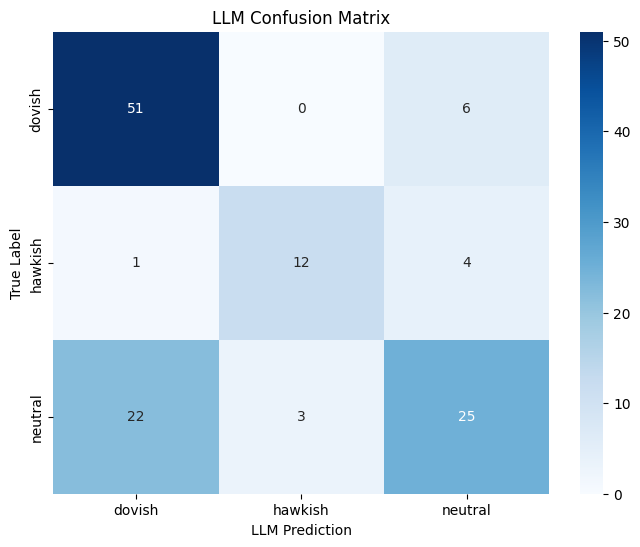

In [0]:
# Calculate accuracy
accuracy = (df_test['sentiment'] == df_test['llm_prediction']).mean()
print(f"\nLLM Accuracy: {accuracy:.3f}")

# Show confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(df_test['sentiment'], df_test['llm_prediction'], 
                      labels=['dovish', 'hawkish', 'neutral'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['dovish', 'hawkish', 'neutral'],
            yticklabels=['dovish', 'hawkish', 'neutral'])
plt.ylabel('True Label')
plt.xlabel('LLM Prediction')
plt.title('LLM Confusion Matrix')
plt.show()